In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib as mpl

In [2]:
mpl.rcParams.update({

    # Font family (Arial if available, else DejaVu Sans)
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],

    # Vector-safe fonts for Nature
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Axis labels
    "axes.labelsize": 18,
    "axes.labelweight": "bold",
    "axes.labelpad": 10,

    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    # Titles
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    # Lines
    "lines.linewidth": 2.2,
    "lines.markersize": 6,

    # Spines
    "axes.linewidth": 1.2,

    # Legend
    "legend.fontsize": 13,
    "legend.frameon": False,
})

In [3]:
files = {
    "CON": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Filtered/FLU/CON/fitness_ALLreps_with_ids.tsv",
    "1/4 MIC": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Filtered/FLU/QMIC/fitness_ALLreps_with_ids.tsv",
    "1/2 MIC": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Filtered/FLU/HMIC/fitness_ALLreps_with_ids.tsv",
    "1 MIC": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Filtered/FLU/FMIC/fitness_ALLreps_with_ids.tsv"
}

dfs = {cond: pd.read_csv(path, sep="\t") for cond, path in files.items()}

In [4]:
# Choose a key to align on (ID is safest if unique)
KEY = "ID"   # or "Lineage"

# Use CON as the reference ordering (you can change this)
ref_cond = "CON"
ref_order = dfs[ref_cond][KEY].astype(str).tolist()
ref_rank = pd.Series(range(len(ref_order)), index=ref_order)

aligned = {}
for cond, df in dfs.items():
    d = df.copy()
    d[KEY] = d[KEY].astype(str)

    # keep only shared lineages across all conditions
    d = d[d[KEY].isin(ref_rank.index)].copy()

    # sort to reference order
    d["__rank__"] = d[KEY].map(ref_rank)
    d = d.sort_values("__rank__").drop(columns="__rank__")

    aligned[cond] = d.reset_index(drop=True)

dfs_aligned = aligned  # use this instead of dfs downstream

print({k: v.shape for k, v in dfs_aligned.items()})

{'CON': (27701, 7), '1/4 MIC': (23857, 7), '1/2 MIC': (23560, 7), '1 MIC': (19450, 7)}


# **Fitness**

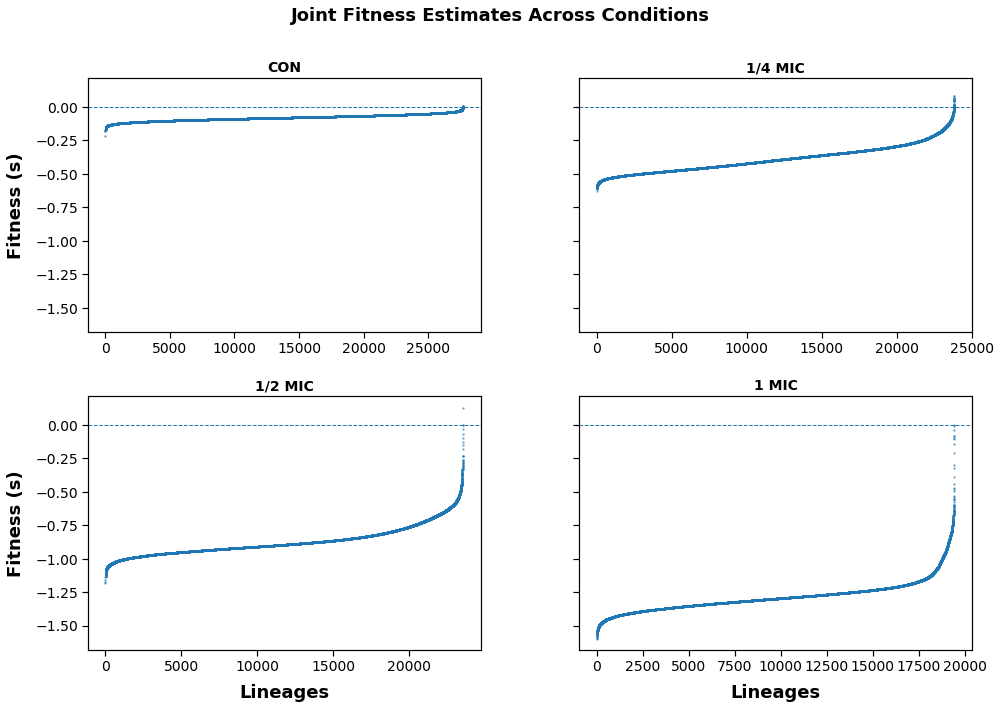

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

n_rows = 2
n_cols = 2

for i, (ax, (cond, df)) in enumerate(zip(axes, dfs.items())):
    row = i // n_cols
    col = i % n_cols

    df_sorted = df.sort_values("s").reset_index(drop=True)

    ax.scatter(
        range(len(df_sorted)),
        df_sorted["s"],
        s=2,
        alpha=0.5
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(cond)

    if col == 0:
        ax.set_ylabel("Fitness (s)")
    else:
        ax.set_ylabel("")

    if row == n_rows - 1:
        ax.set_xlabel("Lineages")
    else:
        ax.set_xlabel("")

plt.suptitle(
    "Joint Fitness Estimates Across Conditions",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

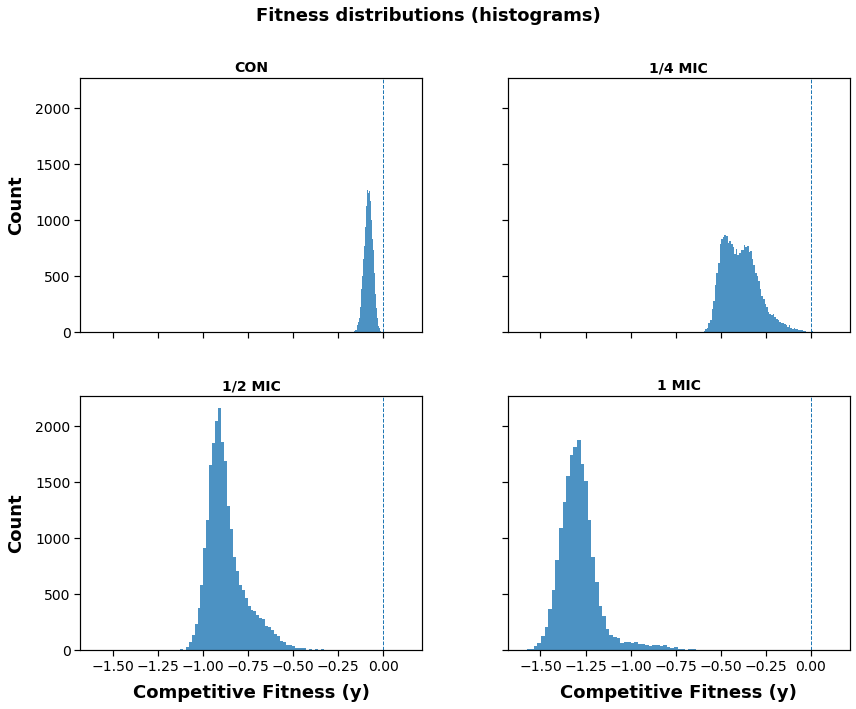

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

n_rows = 2
n_cols = 2

for i, (ax, (cond, df)) in enumerate(zip(axes, dfs_aligned.items())):
    row = i // n_cols
    col = i % n_cols

    ax.hist(df["s"].values, bins=80, alpha=0.8)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(cond)

    if col == 0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")

    if row == n_rows - 1:
        ax.set_xlabel("Competitive Fitness (y)")
    else:
        ax.set_xlabel("")

plt.suptitle(
    "Fitness distributions (histograms)",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

Correlation plots 3x3 panel (6x2 Plots)

In [7]:
# --- Joint fitness files (one per condition)
joint_files = {
    "CON": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Filtered/FLU/CON/fitness_ALLreps_with_ids.tsv",
    "1/4MIC": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Filtered/FLU/QMIC/fitness_ALLreps_with_ids.tsv",
    "1/2MIC": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Filtered/FLU/HMIC/fitness_ALLreps_with_ids.tsv",
    "1MIC": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Filtered/FLU/FMIC/fitness_ALLreps_with_ids.tsv"
}

# --- Independent fitness files: one per condition x replicate
# keys are (condition, replicate_name)
ind_files = {
    ("CON",   "Rep1"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/CON/fitness_rep1_with_ids.tsv",
    ("CON",   "Rep2"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/CON/fitness_rep2_with_ids.tsv",
    ("CON",   "Rep3"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/CON/fitness_rep3_with_ids.tsv",

    ("1/4MIC","Rep1"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/QMIC/fitness_rep1_with_ids.tsv",
    ("1/4MIC","Rep2"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/QMIC/fitness_rep2_with_ids.tsv",
    ("1/4MIC","Rep3"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/QMIC/fitness_rep3_with_ids.tsv",

    ("1/2MIC","Rep1"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/HMIC/fitness_rep1_with_ids.tsv",
    ("1/2MIC","Rep2"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/HMIC/fitness_rep2_with_ids.tsv",
    ("1/2MIC","Rep3"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/HMIC/fitness_rep3_with_ids.tsv",

    ("1MIC",  "Rep1"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/FMIC/fitness_rep1_with_ids.tsv",
    ("1MIC",  "Rep2"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/FMIC/fitness_rep2_with_ids.tsv",
    ("1MIC",  "Rep3"): "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/FMIC/fitness_rep3_with_ids.tsv",
}

KEY = "ID"           # join key
S_COL = "s"          # fitness column name

In [8]:
joint = {cond: pd.read_csv(path, sep="\t") for cond, path in joint_files.items()}
indep = {(cond, rep): pd.read_csv(path, sep="\t") for (cond, rep), path in ind_files.items()}

# ensure ID is string for safe merges
for cond in joint:
    joint[cond][KEY] = joint[cond][KEY].astype(str)

for k in indep:
    indep[k][KEY] = indep[k][KEY].astype(str)

In [9]:
print("joint keys:", list(joint.keys()))
print("indep keys:", sorted(set([k[0] for k in indep.keys()])))

joint keys: ['CON', '1/4MIC', '1/2MIC', '1MIC']
indep keys: ['1/2MIC', '1/4MIC', '1MIC', 'CON']


In [10]:
import numpy as np
from scipy.stats import pearsonr

def plot_joint_vs_ind(ax, joint_df, ind_df, title):
    # Merge on ID
    m = joint_df[[KEY, S_COL]].merge(
        ind_df[[KEY, S_COL]],
        on=KEY,
        suffixes=("_joint", "_ind")
    ).dropna()

    x = m[f"{S_COL}_joint"].values
    y = m[f"{S_COL}_ind"].values

    # Pearson r and R^2
    if len(m) >= 2:
        r, _ = pearsonr(x, y)
        r2 = r ** 2
    else:
        r2 = float("nan")

    # Scatter (legend shows only N and R^2)
    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.5,
        label=f"N = {len(m)}\nR² = {r2:.3f}"
    )

    # Regression line (least squares)
    if len(m) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 200)
        ys = slope * xs + intercept
        ax.plot(xs, ys, linewidth=2, alpha=0.8)

    ax.set_title(title)
    ax.set_xlabel("Joint competitive fitness, y(t)")
    ax.set_ylabel("Replicate-specific competitive fitness, yᵣ(t)")

    ax.legend(
        loc="best",
        frameon=True,
        handlelength=0,   # hide marker/line in legend
        handletextpad=0
    )

    return m, r2

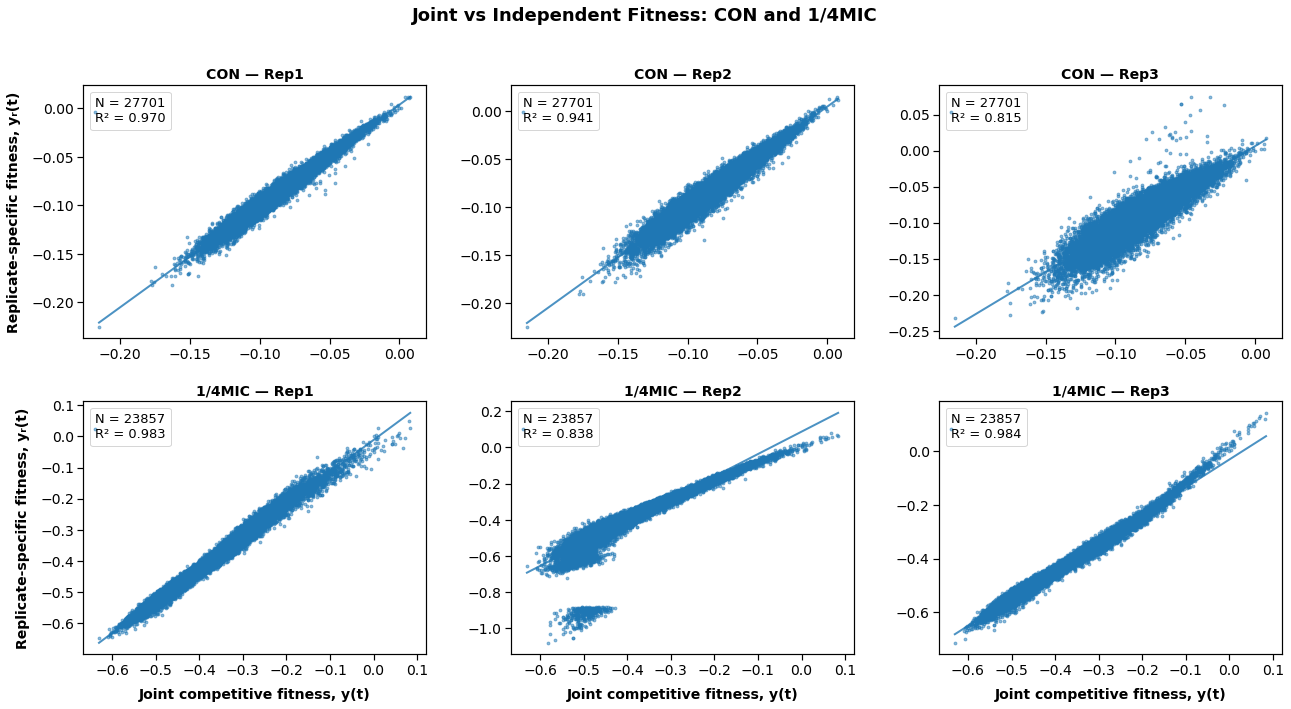

In [11]:
conds = ["CON", "1/4MIC"]
reps = ["Rep1", "Rep2", "Rep3"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False)

n_rows = len(conds)
n_cols = len(reps)

#local override font sizes
AX_LABEL_FONTSIZE = 14   # decrease from global 18

for row, cond in enumerate(conds):
    for col, rep in enumerate(reps):
        ax = axes[row, col]
        title = f"{cond} — {rep}"
        plot_joint_vs_ind(ax, joint[cond], indep[(cond, rep)], title)

        # Y-axis label only for first column
        if col == 0:
            ax.set_ylabel(
                "Replicate-specific fitness, yᵣ(t)",
                fontsize=AX_LABEL_FONTSIZE,
                fontweight="bold"
            )
        else:
            ax.set_ylabel("")

        # X-axis label only for bottom row
        if row == n_rows - 1:
            ax.set_xlabel(
                "Joint competitive fitness, y(t)",
                fontsize=AX_LABEL_FONTSIZE,
                fontweight="bold"
            )
        else:
            ax.set_xlabel("")

plt.suptitle(
    "Joint vs Independent Fitness: CON and 1/4MIC",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

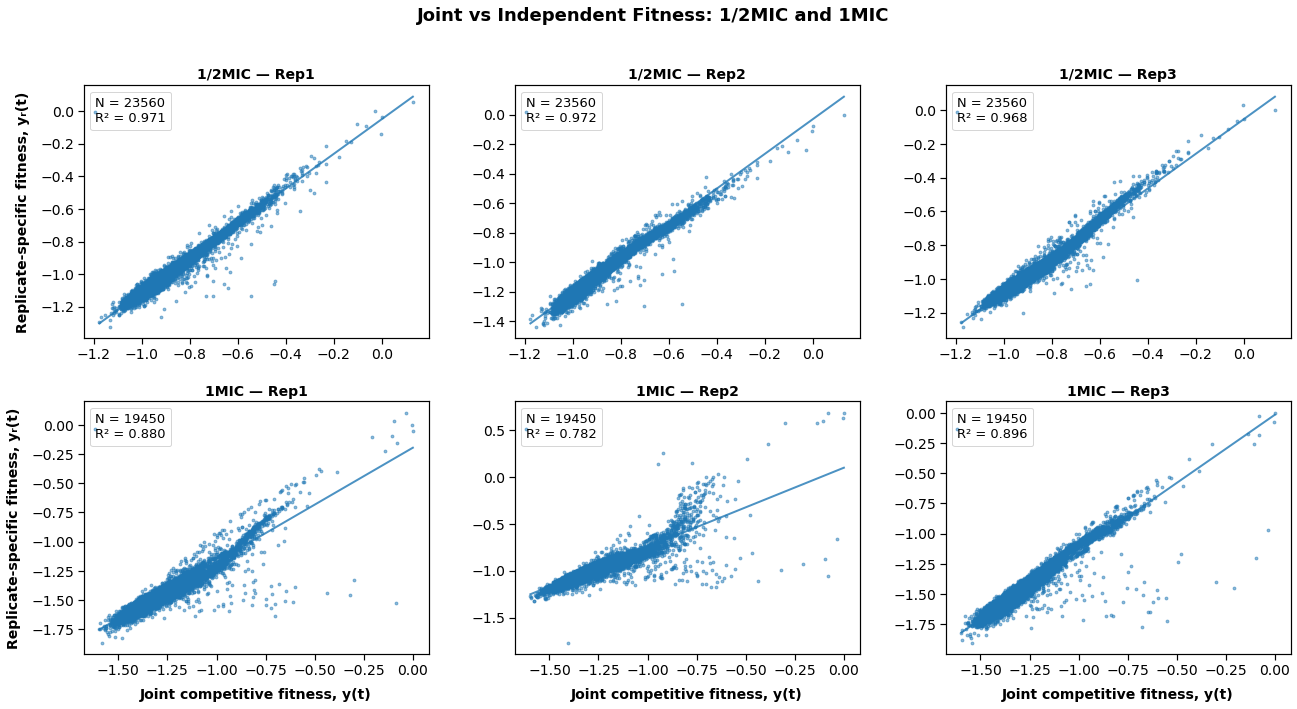

In [12]:
conds = ["1/2MIC", "1MIC"]
reps = ["Rep1", "Rep2", "Rep3"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False)

n_rows = len(conds)
n_cols = len(reps)

#local override font size for axis titles
AX_LABEL_FONTSIZE = 14   # smaller than global 18

for row, cond in enumerate(conds):
    for col, rep in enumerate(reps):
        ax = axes[row, col]
        title = f"{cond} — {rep}"
        plot_joint_vs_ind(ax, joint[cond], indep[(cond, rep)], title)

        # Y-axis label only for first column
        if col == 0:
            ax.set_ylabel(
                "Replicate-specific fitness, yᵣ(t)",
                fontsize=AX_LABEL_FONTSIZE,
                fontweight="bold"
            )
        else:
            ax.set_ylabel("")

        # X-axis label only for bottom row
        if row == n_rows - 1:
            ax.set_xlabel(
                "Joint competitive fitness, y(t)",
                fontsize=AX_LABEL_FONTSIZE,
                fontweight="bold"
            )
        else:
            ax.set_xlabel("")

plt.suptitle(
    "Joint vs Independent Fitness: 1/2MIC and 1MIC",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

# **LINEAGE TRAJECTORY**

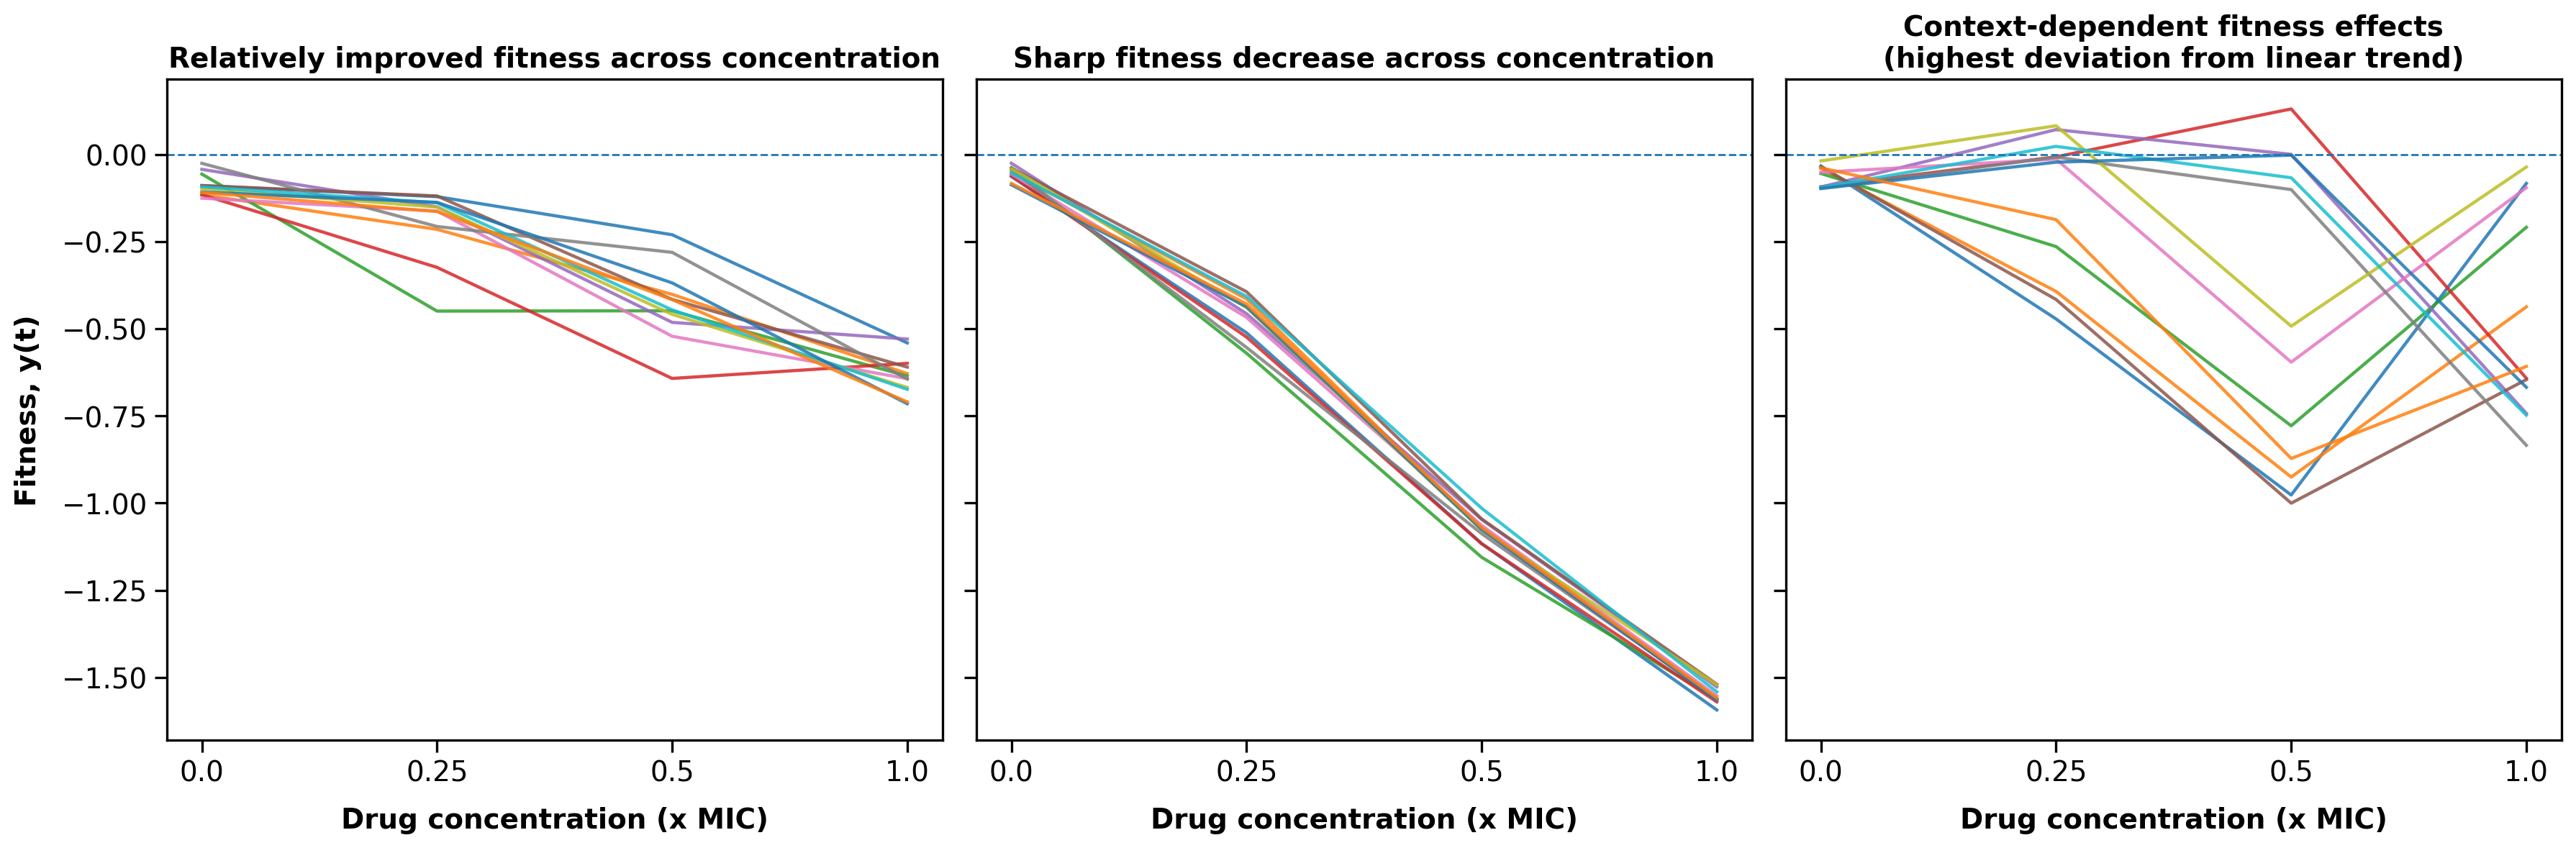

Panel counts shown:
  Increasing (highest slopes): 12
  Decreasing (lowest slopes):  12
  Nonlinear (top 15% SSE): 12

Slope ranges:
  max slope: 0.004225
  min slope: -0.519361

Lineages with positive slope (>0): 1 / 17542


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KEY = "ID"
S_COL = "s"

conds = ["CON", "1/4MIC", "1/2MIC", "1MIC"]
xlabels = ["0.0", "0.25", "0.5", "1.0"]
x = np.arange(len(conds), dtype=float)

N_PER_PANEL = 12          # how many lineages per panel
NONLIN_FRAC = 0.15        # nonlinear = top 15% by SSE from linear fit (adjust)

# ---------- Build wide table (complete trajectories only) ----------
wide = None
for cond in conds:
    df = joint[cond].copy()
    df[KEY] = df[KEY].astype(str)
    df = df[[KEY, S_COL]].rename(columns={S_COL: f"s_{cond}"})
    wide = df if wide is None else wide.merge(df, on=KEY, how="inner")

S = wide[[f"s_{c}" for c in conds]].to_numpy(dtype=float)

# ---------- Compute slope + nonlinearity (SSE from linear fit) ----------
slopes = np.zeros(len(S))
sse = np.zeros(len(S))

for i, y in enumerate(S):
    slope, intercept = np.polyfit(x, y, 1)
    yhat = slope * x + intercept
    slopes[i] = slope
    sse[i] = np.sum((y - yhat) ** 2)

# ---------- Define nonlinear set (top fraction by SSE) ----------
thr = np.quantile(sse, 1 - NONLIN_FRAC)
nonlin_idx = np.where(sse >= thr)[0]

# To avoid the nonlinear lines also showing up in inc/dec panels, exclude them there:
linearish_idx = np.where(sse < thr)[0]

# ---------- Pick representatives ----------
# "Increasing" = highest slopes among (mostly linear) trajectories
inc_pick = linearish_idx[np.argsort(slopes[linearish_idx])[::-1]][:N_PER_PANEL]

# "Decreasing" = lowest slopes among (mostly linear) trajectories
dec_pick = linearish_idx[np.argsort(slopes[linearish_idx])][:N_PER_PANEL]

# "Nonlinear" = highest SSE (most curved)
nonlin_pick = nonlin_idx[np.argsort(sse[nonlin_idx])[::-1]][:N_PER_PANEL]

# ---------- Plot ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=200, sharey=True)

panels = [
    ("Relatively improved fitness across concentration", inc_pick),
    ("Sharp fitness decrease across concentration", dec_pick),
    ("Context-dependent fitness effects\n(highest deviation from linear trend)", nonlin_pick),
]

for ax, (title, idxs) in zip(axes, panels):
    for idx in idxs:
        ax.plot(x, S[idx], linewidth=1.6, alpha=0.85)

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Drug concentration (x MIC)", fontsize=14, fontweight="bold")

axes[0].set_ylabel("Fitness, y(t)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ---------- Diagnostics ----------
print("Panel counts shown:")
print(f"  Increasing (highest slopes): {len(inc_pick)}")
print(f"  Decreasing (lowest slopes):  {len(dec_pick)}")
print(f"  Nonlinear (top {int(NONLIN_FRAC*100)}% SSE): {len(nonlin_pick)}")

print("\nSlope ranges:")
print(f"  max slope: {slopes.max():.6f}")
print(f"  min slope: {slopes.min():.6f}")

# Optional: show if any truly positive-slope lineages exist
n_pos = int((slopes > 0).sum())
print(f"\nLineages with positive slope (>0): {n_pos} / {len(slopes)}")

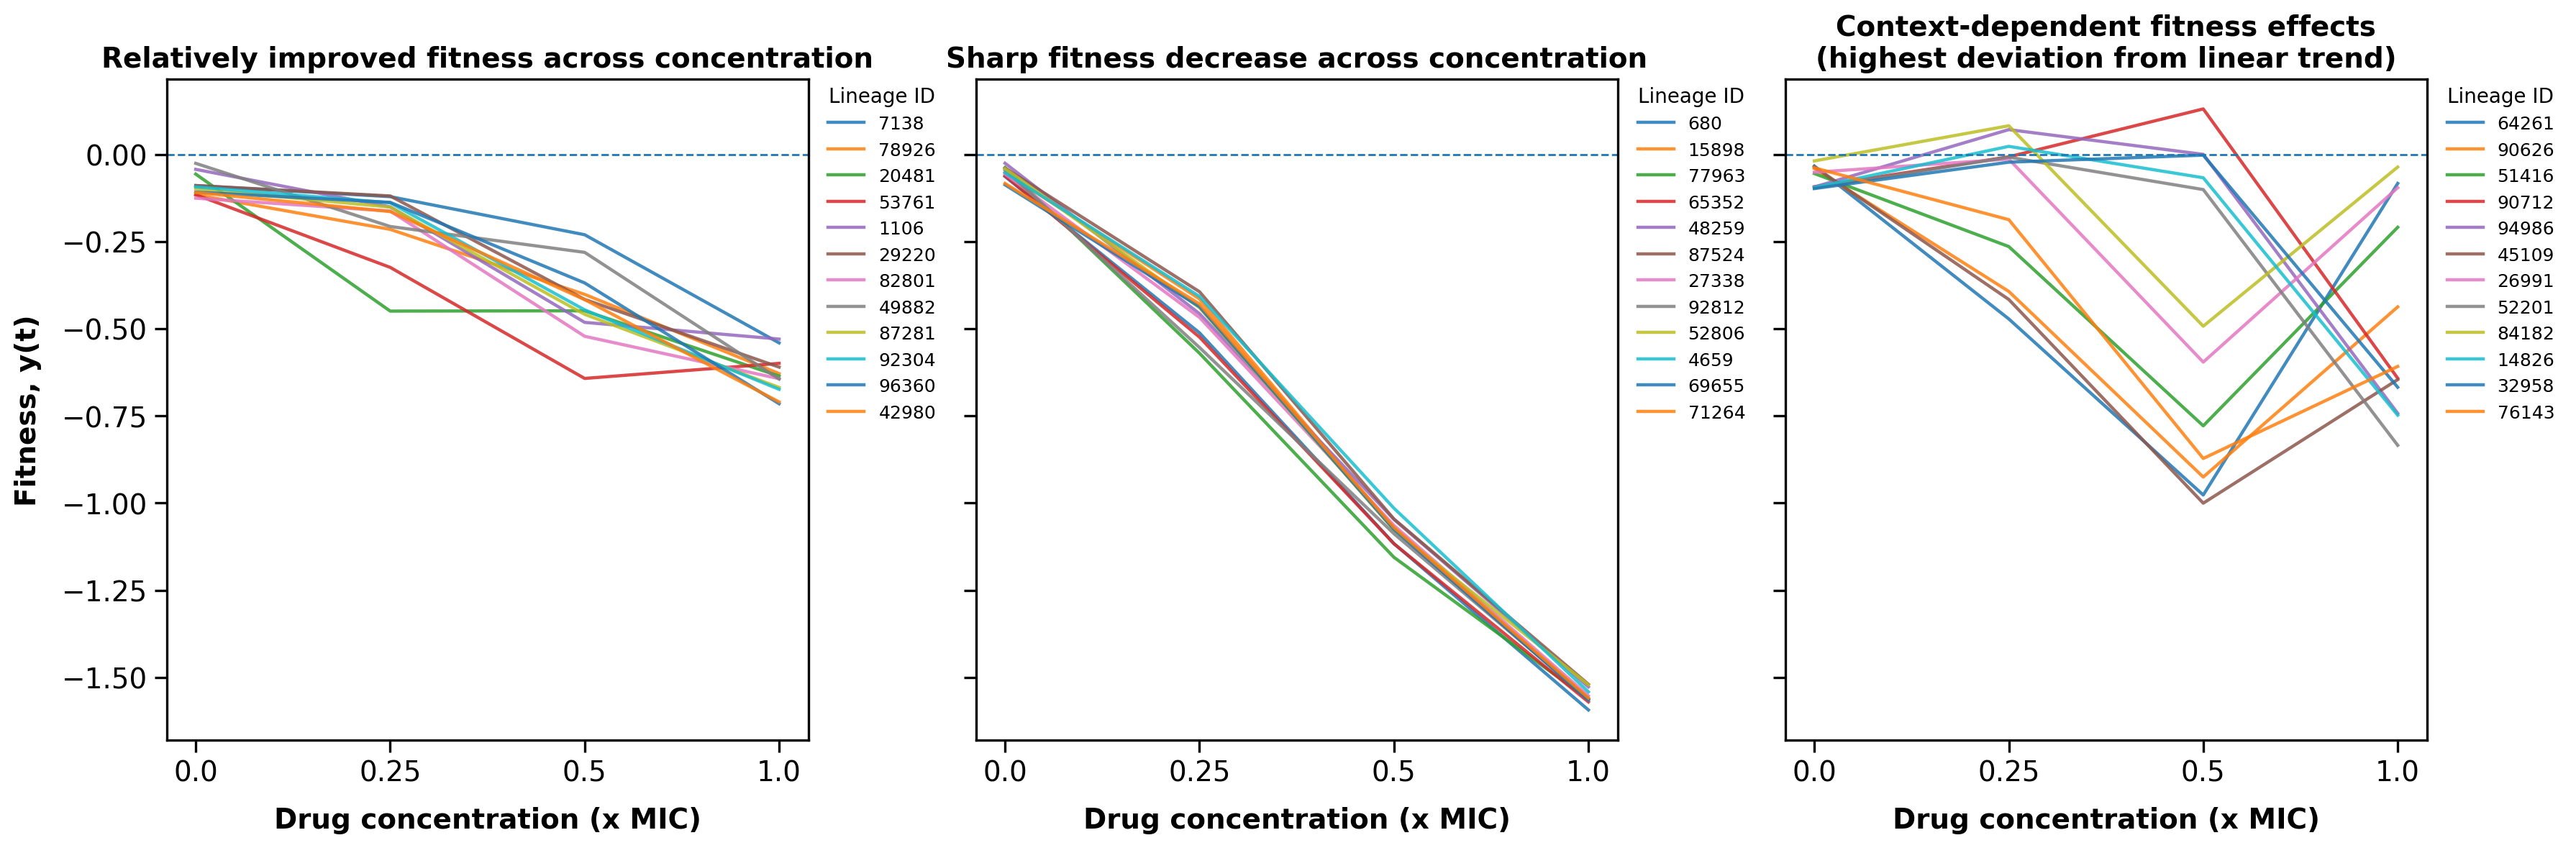

In [15]:
# ---------- Plot ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=200, sharey=True)

panels = [
    ("Relatively improved fitness across concentration", inc_pick),
    ("Sharp fitness decrease across concentration", dec_pick),
    ("Context-dependent fitness effects\n(highest deviation from linear trend)", nonlin_pick),
]

for ax, (title, idxs) in zip(axes, panels):
    for idx in idxs:
        lineage_id = wide.iloc[idx][KEY]
        ax.plot(
            x,
            S[idx],
            linewidth=1.6,
            alpha=0.85,
            label=str(lineage_id)   #legend label = lineage ID
        )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Drug concentration (x MIC)", fontsize=14, fontweight="bold")

    #Add legend (outside axis)
    ax.legend(
        title="Lineage ID",
        fontsize=9,
        title_fontsize=10,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        frameon=False,
        ncol=1
    )

axes[0].set_ylabel("Fitness, y(t)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()